Обучение и метрики для сегментации изображений приводимых к формату 768х768 с помощью Unet++. Также сохраняются веса для последующего использования.

In [15]:
from pathlib import Path

ROOT = Path("D:/diplom/dataset_segment")
IMG_DIR = ROOT / "images"
MASK_DIR = ROOT / "masks"

WEIGHTS_DIR = Path("D:/diplom/weights")
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

In [16]:
import random
from glob import glob

images = sorted(glob(str(IMG_DIR / "*.png")))
masks  = [str(MASK_DIR / Path(img).name) for img in images]

pairs = list(zip(images, masks))
random.shuffle(pairs)

split = int(len(pairs) * 0.8)
train_pairs = pairs[:split]
val_pairs   = pairs[split:]

len(train_pairs), len(val_pairs)

(480, 120)

In [17]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
import albumentations as A

IMAGE_SIZE = 768

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.1, rotate_limit=10, p=0.7),
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
])

class SegDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is None:
            raise RuntimeError(f"BAD IMAGE {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
        if mask is None:
            raise RuntimeError(f"BAD MASK {mask_path}")

        # Если RGBA → оставляем RGB
        if len(mask.shape) == 3 and mask.shape[2] == 4:
            mask = mask[:, :, :3]

        # Если маска одноканальная — не трогаем
        if len(mask.shape) == 3 and mask.shape[2] == 3:
            red   = mask[:, :, 2] > 100
            green = mask[:, :, 1] > 100

            new_mask = np.zeros(mask.shape[:2], dtype=np.uint8)
            new_mask[green] = 1
            new_mask[red]   = 2
            mask = new_mask

        if mask.shape[:2] != img.shape[:2]:
            raise RuntimeError(f"SIZE MISMATCH {img_path}")

        augmented = self.transform(image=img, mask=mask)
        img, mask = augmented["image"], augmented["mask"]

        img = img.astype("float32") / 255.0
        img = np.transpose(img, (2, 0, 1))

        return torch.tensor(img), torch.tensor(mask).long()


In [18]:
from torch.utils.data import DataLoader

train_dataset = SegDataset(train_pairs, train_transform)
val_dataset   = SegDataset(val_pairs, val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)


In [19]:
import segmentation_models_pytorch as smp
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3,     # фон =0, ооцит =1, игла =2
    activation=None
).to(DEVICE)


In [20]:
import torch.nn as nn
from torch.amp import GradScaler, autocast
from tqdm import tqdm

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scaler = GradScaler('cuda')
best_loss = 9999

for epoch in range(25):
    model.train()
    train_loss = 0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1} TRAIN"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()

        # === AMP ускорение forward + loss ===
        with autocast('cuda'):
            preds = model(imgs)
            loss = loss_fn(preds, masks)

        # === AMP backward ===
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    # === Validation (без AMP, в обычном режиме) ===
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch+1} VAL"):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            val_loss += loss_fn(preds, masks).item()

    print(f"Epoch {epoch+1}: "
          f"train={train_loss/len(train_loader):.4f}, "
          f"val={val_loss/len(val_loader):.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), WEIGHTS_DIR / "unetpp768_oocyte.pth")
        print("✔ Model saved!")


Epoch 1 VAL: 100%|██████████| 30/30 [01:11<00:00,  2.37s/it]


Epoch 1: train=0.5312, val=0.2827
✔ Model saved!


Epoch 2 VAL: 100%|██████████| 30/30 [01:10<00:00,  2.35s/it]


Epoch 2: train=0.1824, val=0.1294
✔ Model saved!


Epoch 3 VAL: 100%|██████████| 30/30 [01:11<00:00,  2.39s/it]


...

Epoch 23: train=0.0078, val=0.0092
✔ Model saved!


Epoch 24 VAL: 100%|██████████| 30/30 [01:10<00:00,  2.34s/it]


Epoch 24: train=0.0076, val=0.0094


Epoch 25 VAL: 100%|██████████| 30/30 [01:10<00:00,  2.35s/it]

Epoch 25: train=0.0074, val=0.0095


In [21]:
def predict_mask(model, img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    augmented = val_transform(image=img)
    img_t = augmented["image"].astype("float32") / 255.0
    img_t = np.transpose(img_t, (2, 0, 1))
    img_t = torch.tensor(img_t).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(img_t)
        pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

    return pred

In [22]:
def iou_score(pred, true, num_classes=3):
    ious = []
    pred = pred.view(-1)
    true = true.view(-1)

    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = true == cls

        intersection = (pred_inds[target_inds]).sum().item()
        union = pred_inds.sum().item() + target_inds.sum().item() - intersection

        if union == 0:
            ious.append(1.0)
        else:
            ious.append(intersection / union)

    return sum(ious) / num_classes


def dice_score(pred, true, num_classes=3):
    dices = []
    pred = pred.view(-1)
    true = true.view(-1)

    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = true == cls
        
        intersection = (pred_inds[target_inds]).sum().item()
        dice = (2.0 * intersection) / (pred_inds.sum().item() + target_inds.sum().item() + 1e-7)
        dices.append(dice)

    return sum(dices) / num_classes

In [23]:
pixel_acc = lambda pr, gt: (pr == gt).float().mean()

sum_iou = 0
sum_dice = 0
sum_acc = 0
count = 0

model.eval()

with torch.no_grad():
    for imgs, masks in tqdm(val_loader, desc="Evaluating"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        preds = model(imgs)
        preds = torch.argmax(preds, dim=1)

        sum_iou  += iou_score(preds.cpu(), masks.cpu(), num_classes=3)
        sum_dice += dice_score(preds.cpu(), masks.cpu(), num_classes=3)
        sum_acc  += (preds == masks).float().mean().item()

        count += 1

mean_iou  = sum_iou / count
mean_dice = sum_dice / count
mean_acc  = sum_acc / count

print(f"IoU:   {mean_iou:.4f}")
print(f"Dice:  {mean_dice:.4f}")
print(f"Pixel accuracy: {mean_acc:.4f}")


Evaluating: 100%|██████████| 30/30 [01:11<00:00,  2.38s/it]

IoU:   0.9547
Dice:  0.9761
Pixel accuracy: 0.9967


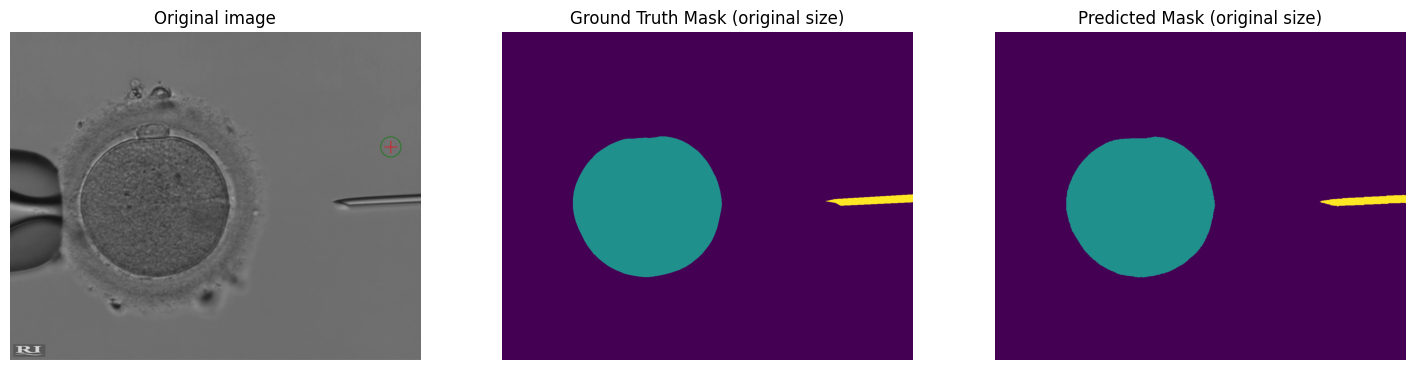

In [24]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch

def show_prediction(model, img_path, mask_path):
    model.eval()

    # --- Load original image ---
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img_rgb.shape[:2]

    # --- Load ground truth mask ---
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    # Convert GT to class mask
    if len(gt_mask.shape) == 3:
        red   = gt_mask[:, :, 2] > 100
        green = gt_mask[:, :, 1] > 100
        mask_new = np.zeros(gt_mask.shape[:2], dtype=np.uint8)
        mask_new[green] = 1
        mask_new[red] = 2
        gt_mask = mask_new

    # --- Predict mask ---
    augmented = val_transform(image=img_rgb)
    img_t = augmented["image"].astype("float32") / 255.0
    img_t = np.transpose(img_t, (2, 0, 1))
    img_t = torch.tensor(img_t).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(img_t)
        pred_mask = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

    # === Restore predicted mask to original resolution ===
    pred_mask_resized = cv2.resize(
        pred_mask.astype(np.uint8),
        (orig_w, orig_h),
        interpolation=cv2.INTER_NEAREST
    )

    gt_mask_resized = cv2.resize(
        gt_mask.astype(np.uint8),
        (orig_w, orig_h),
        interpolation=cv2.INTER_NEAREST
    )

    # --- Plot all three images ---
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.title("Original image")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth Mask (original size)")
    plt.imshow(gt_mask_resized, cmap="viridis")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask (original size)")
    plt.imshow(pred_mask_resized, cmap="viridis")
    plt.axis("off")

    plt.show()



# --- ВЫЗОВ НА ОДНОМ ТЕСТОВОМ ИЗОБРАЖЕНИИ ---
test_img, test_mask = val_pairs[1]
show_prediction(model, test_img, test_mask)
